In [ ]:

# 3. 기본 툴 업데이트
!pip install -U pip setuptools wheel

# 4. AutoGluon 고정 버전 설치
!pip install autogluon==1.4.0 --extra-index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtr

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 데이터 파일 압축해제 및 로드
!cp "/content/drive/MyDrive/Colab Notebooks/open_track1_colab.zip" "/content/" # 드라이브 파일을 코랩 환경으로 불러옴
!unzip 'open_track1_colab.zip'
print('✅ 데이터 로드 완료')

Mounted at /content/drive
Archive:  open_track1_colab.zip
   creating: open_track1_colab/
   creating: open_track1_colab/.vscode/
  inflating: open_track1_colab/.vscode/settings.json  
   creating: open_track1_colab/AutogluonModels/
  inflating: open_track1_colab/data_description.xlsx  
  inflating: open_track1_colab/match_info.csv  
  inflating: open_track1_colab/reg_13B copy 2.ipynb  
  inflating: open_track1_colab/reg_13B copy 3.ipynb  
  inflating: open_track1_colab/reg_13B copy 4.ipynb  
  inflating: open_track1_colab/reg_13B copy.ipynb  
  inflating: open_track1_colab/reg_13B.ipynb  
  inflating: open_track1_colab/reg_13B_2.ipynb  
  inflating: open_track1_colab/reg_14 copy.ipynb  
  inflating: open_track1_colab/reg_14.ipynb  
  inflating: open_track1_colab/reg_99.ipynb  
  inflating: open_track1_colab/sample_submission.csv  
   creating: open_track1_colab/test/
   creating: open_track1_colab/test/153363/
  inflating: open_track1_colab/test/153363/153363_1.csv  
  inflating: open

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder
from autogluon.tabular import TabularPredictor

In [ ]:
TRAIN_PATH = "/content/open_track1_colab/train.csv"

In [ ]:
df_raw = pd.read_csv("/content/open_track1_colab/train.csv")
print(df_raw.head(3))

   game_id  period_id  episode_id  time_seconds  team_id  player_id  \
0   126283          1           1         0.667     2354     344559   
1   126283          1           1         3.667     2354     250036   
2   126283          1           1         4.968     2354     500145   

   action_id type_name result_name    start_x    start_y      end_x  \
0          0      Pass  Successful  52.418205  33.485444  31.322445   
1          2      Pass  Successful  32.013240  38.100808  37.371285   
2          4     Carry         NaN  37.371285  30.632980  38.391570   

       end_y  is_home game_episode  
0  38.274752     True     126283_1  
1  30.632980     True     126283_1  
2  24.613144     True     126283_1  


In [ ]:
df = df_raw.sort_values(["game_episode", "time_seconds"]).reset_index(drop=True)

In [ ]:
def preprocess_df(df, mode='Train'):
    features = []
    targets = []
    data_source = [] # (g, name) 튜플 리스트

    # --- 1단계: 모드별 데이터 소스 준비 ---
    if mode == 'Train':
        # Train: df를 'game_episode'로 그룹화
        data_source = [(g.reset_index(drop=True), name)
                       for name, g in df.groupby("game_episode")]
        desc = "Train Groups"

    elif mode == 'Test':
        # Test: df(submission)의 각 행을 순회하며 'path' 파일 로드
        for _, row in df.iterrows():
            # Corrected: Use row["path"] directly as it's already properly formed
            correct_path = row["path"]
            try:
                g = pd.read_csv(correct_path).reset_index(drop=True)
                g = g.reset_index(drop=True)
                data_source.append((g, os.path.basename(row["path"])))
            except Exception as e:
                print(f"⚠️ Error reading file {correct_path}: {e}. Skipping.")
                continue
        desc = "Test Files"

    else:
        raise ValueError("❌ mode는 'Train' 또는 'Test'만 가능합니다.")
    # --- 2단계: 공통 전처리 로직 실행 ---
    if data_source:
        for g, name in tqdm(data_source, total=len(data_source), desc=desc):
            if len(g) < 2:
                continue
            g['action_result'] = g['type_name'] + g['result_name'].fillna('_')
            # g['dx'] = g['start_x'] - g['end_x']
            # g['dy'] = g['start_y'] - g['end_y']

            # 일반특성
            dt = g['time_seconds'].values[-1] - g['time_seconds'].values[-2]
            is_successful = g['result_name'].values[-1] == 'Successful'
            last_act = g['action_result'].values[-2]
            # average_time = (g['time_seconds'].values[-1]-g['time_seconds'].values[0]) / (len(g)-1)
            same_team = g['is_home'].values[0] == g['is_home'].values[-1]

            if same_team == True:
                origin_x = g['start_x'].values[0]
                origin_y = g['start_y'].values[0]
            else:
                origin_x = 105 - g['start_x'].values[0]
                origin_y = 68 - g['start_y'].values[0]

            # 선수특성
            current_player_id = g['player_id'].values[-1]
            player_actions = g[g['player_id'] == current_player_id].reset_index(drop=True)

            pdt = None
            pdx = None
            pdy = None

            if len(player_actions) >= 2:
                last_player_action = player_actions.iloc[-1]
                # Default to the immediately preceding action
                second_last_player_action = player_actions.iloc[-2]

                # If there are at least 3 actions and the action_ids are consecutive,
                # then use the third-to-last action as second_last_player_action.
                if len(player_actions) >= 3 and \
                   (last_player_action['action_id'] - second_last_player_action['action_id'] == 1):
                    second_last_player_action = player_actions.iloc[-3]

                pdt = last_player_action['time_seconds'] - second_last_player_action['time_seconds']

                # Start and end coordinates of the second to last action of this player
                p_x_start = second_last_player_action['start_x']
                p_y_start = second_last_player_action['start_y']
                p_x_end = second_last_player_action['end_x']
                p_y_end = second_last_player_action['end_y']

                pdx = p_x_end - p_x_start
                pdy = p_y_end - p_y_start

            # 좌표특성
            if g['is_home'].values[-1] == g['is_home'].values[-2]:
                x_2, y_2 = g['start_x'].values[-2], g['start_y'].values[-2]
                x_2e, y_2e = g['end_x'].values[-2], g['end_y'].values[-2]
            else:
                x_2, y_2 = (105-g['start_x'].values[-2]), (68-g['start_y'].values[-2])
                x_2e, y_2e = (105-g['end_x'].values[-2]), (68-g['end_y'].values[-2])
            x_1, y_1 = g['start_x'].values[-1], g['start_y'].values[-1]

            origin_x_diff = x_1 - origin_x
            origin_y_diff = y_1 - origin_y

            dx, dy = x_2e-x_2, y_2e-y_2
            move_dist = np.sqrt((dx)**2 + (dy)**2)

            theta = np.arctan2(dx, dy)
            if move_dist == 0.0:
                sin, cos = None, None
            else:
                sin, cos = np.sin(theta), np.cos(theta)

            if dt == 0.0:
                x_speed = 0
                y_speed = 0
            else:
                x_speed = dx/dt
                y_speed = dy/dt

            # 센터특성
            x_c, y_c = np.array(x_1-52.5), np.array(y_1-34)
            center_dist = np.sqrt((x_c)**2 +(y_c)**2)
            center_dist_2 = np.sqrt((x_2-52.5)**2 +(y_2-34)**2)
            center_theta = np.arctan2(x_c, y_c)
            center_sin, center_cos = np.sin(center_theta), np.cos(center_theta)

            # 오차조정
            x_error, y_error = x_1-x_2e, y_1-y_2e
            theta_error = np.arctan2(x_error, y_error)
            sin_error, cos_error = np.sin(theta_error), np.cos(theta_error)

            # 3차 특성
            if len(g) > 2:
                last_act_2 = g['action_result'].values[-3]
                dt_2 = g['time_seconds'].values[-2] - g['time_seconds'].values[-3]
                if g['is_home'].values[-1] == g['is_home'].values[-3]:
                    x_3, y_3 = g['start_x'].values[-3], g['start_y'].values[-3]
                    x_3e, y_3e = g['end_x'].values[-3], g['end_y'].values[-3]
                else:
                    x_3, y_3 = (105-g['start_x'].values[-3]), (68-g['start_y'].values[-3])
                    x_3e, y_3e = (105-g['end_x'].values[-3]), (68-g['end_y'].values[-3])

                dx_2, dy_2 = x_3e-x_3, y_3e-y_3
                move_dist2 = np.sqrt((dx_2)**2 + (dy_2)**2)

                theta_2 = np.arctan2(dx_2, dy_2)
                if move_dist2 == 0.0:
                    sin_2, cos_2 = None, None
                else:
                    sin_2, cos_2 = np.sin(theta_2), np.cos(theta_2)

                if dt_2 == 0.0:
                    x2_speed = 0
                    y2_speed = 0
                else:
                    x2_speed = dx_2/dt_2
                    y2_speed = dy_2/dt_2

                dt_diff = dt-dt_2
                dx_diff, dy_diff = dx-dx_2, dy-dy_2 # 낮은성능
                theta_diff = theta - theta_2    # 낮은성능
                sin_diff, cos_diff = np.sin(theta_diff), np.cos(theta_diff)
                speed_xdiff = x_speed-x2_speed
                speed_ydiff = y_speed-y2_speed
                is_home_diff = g['is_home'].values[-3] == g['is_home'].values[-1]
                P3 = g['player_id'].values[-3] == g['player_id'].values[1]

            else:
                last_act_2 = None
                dt_2 = None
                dt_diff = None
                dx_diff, dy_diff = None, None
                sin_diff, cos_diff = None, None
                speed_xdiff = None
                speed_ydiff = None
                is_home_diff = None
                P3 = None

            is_confident = (dt == 0) & (last_act=='Recovery_') & (is_successful == True)
            special_case = (dt == 0) & (last_act_2=='TackleSuccessful') & (is_successful == True)

            # 타깃
            x_0 = g['end_x'].values[-1]
            y_0 = g['end_y'].values[-1]

            features.append({
                'x_2e' : x_2e,
                'y_2e' : y_2e,
                'x_1': x_1,
                'y_1': y_1,
                'sin' : sin,
                'cos' : cos,
                'dt' : dt,
                'x_speed' : x_speed,
                'y_speed' : y_speed,
                'last_act' : last_act,
                'is_successful' : is_successful,
                # 'is_one_team' : is_one_team,
                # 'center_dist' : center_dist,
                # 'center_sin' : center_sin,
                # 'center_cos' : center_cos,
                # 'move_dist' : move_dist,
                'x_error' : x_error,
                'y_error' : y_error,
                'cos_error' : cos_error,
                'sin_error' : sin_error,
                # 'pdt' : pdt,
                # 'pdx' : pdx,
                # 'pdy' : pdy,
                # 'x_3' : x_3,
                # 'y_3' : y_3,
                'x_3e' : x_3e,
                'y_3e' : y_3e,
                'last_act_2' : last_act_2,
                'dt_2' : dt_2,
                # 'average_time' : average_time,
                # 'P3' : P3,
                # 'is_home_diff' : is_home_diff,
                # 'x2_speed' : x2_speed,
                # 'y2_speed' : y2_speed,
                # 'sin_2' : sin_2,
                # 'cos_2' : cos_2,
            })
            targets.append({'x_0': x_0, 'y_0': y_0})
        if mode=='Train':
            return pd.DataFrame(features), pd.DataFrame(targets)
        elif mode=='Test':
            return pd.DataFrame(features)
        else:
            # This case (mode not 'Train' or 'Test') should be caught by ValueError above.
            # If somehow reached, it should return consistent types.
            print('Invalid mode. Returning empty DataFrames.')
            return pd.DataFrame(), pd.DataFrame() # Return empty DataFrames for consistency
    else:
        # Handle cases where data_source is empty (e.g., no files found or loaded)
        if mode == 'Train':
            print("No training data loaded. Returning empty DataFrames.")
            return pd.DataFrame(), pd.DataFrame()
        elif mode == 'Test':
            print("No test data loaded. Returning empty DataFrame.")
            return pd.DataFrame() # Return an empty DataFrame for test mode
        else:
            print('Invalid mode and no data loaded. Returning empty DataFrames.')
            return pd.DataFrame(), pd.DataFrame()


# 반복문 종료 후, 리스트를 사용하여 새로운 DataFrame 생성
df_features, df_targets = preprocess_df(df)

df_features.head(3)

Train Groups: 100%|██████████| 15435/15435 [00:22<00:00, 699.36it/s]


,x_2e,y_2e,x_1,y_1,sin,cos,dt,x_speed,y_speed,last_act,is_successful,x_error,y_error,cos_error,sin_error,x_3e,y_3e,last_act_2,dt_2
0,101.054205,52.757324,101.054205,52.757324,0.977979,-0.208704,2.034,7.306121,-1.559152,Carry_,True,0.0,0.0,1.0,0.0,86.193555,55.928640,Recovery_,0.000
1,102.213510,51.930444,102.213510,51.930444,-0.170852,-0.985297,1.148,-2.427256,-13.997871,Pass_CornerSuccessful,True,0.0,0.0,1.0,0.0,86.193555,55.928640,None,NaN
2,67.934265,11.028172,67.934265,11.028172,0.777249,0.629193,1.036,4.468277,3.617127,Carry_,True,0.0,0.0,1.0,0.0,63.305130,7.280828,PassSuccessful,0.735


In [ ]:
def manual_estimate(df_features):
    # 1. 조건 정의 (모두 Boolean Series로 생성)
    df = df_features.copy()
    cond1 = (df['dt'] == 0)
    cond2 = (df['last_act_2'] == 'TackleSuccessful')

    mask1 = cond1
    df.loc[mask1, 'x_0'] = df.loc[mask1, 'x_2e']
    df.loc[mask1, 'y_0'] = df.loc[mask1, 'y_2e']

    mask2 = cond1 & cond2
    df.loc[mask2, 'x_0'] = df.loc[mask2, 'x_3e']
    df.loc[mask2, 'y_0'] = df.loc[mask2, 'y_3e']

    df = df[df['x_0'].notna()][['x_0', 'y_0']]

    return df.astype('float32')

In [ ]:
manual_estimation = manual_estimate(df_features)
len(manual_estimation)

1744

In [ ]:
full_data = pd.concat([df_features, df_targets], axis=1)

# 이상치 제거
def delete_outliers(df):
    # 1. 각 이상치 조건 정의 (df 기준)
    cond1 = (df['x_1'] - df['x_0'] == 0)
    cond2 = (df['dt'] > 99)
    cond3 = (df['x_3e'] - df['x_0'] == 0) & (df['dt'] != 0)
    cond4 = (df['last_act'].isin(['Clearance_', 'DuelUnsuccessful']))

    is_outlier = cond1 | cond2 | cond3 | cond4
    df_cleaned = df[~is_outlier].copy()

    print(f"제거된 이상치: {is_outlier.sum()}행")

    return df_cleaned

full_data = delete_outliers(full_data)

제거된 이상치: 11행


In [ ]:
def coord_extract(full_data, coord, k=0):
    df = full_data.copy()
    if coord == 'X':
        if k>0:
            df['x_delta'] = df['x_0'] - df['x_1']
            df = df.sort_values(by='x_delta').iloc[k:-k]
        drop_cols = ['y_2e', 'cos', 'y_error', 'last_act_2', 'x_3e', 'y_3e', 'x_delta', 'y_delta']
    elif coord == 'Y':
        if k>0:
            df['y_delta'] = df['y_0'] - df['y_1']
            df = df.sort_values(by='y_delta').iloc[k:-k]
        drop_cols = ['x_2e', 'sin', 'x_error', 'last_act_2', 'x_3e', 'y_3e', 'x_delta', 'y_delta']
    else:
        raise ValueError("coord 인자는 'X' 또는 'Y'여야 합니다.")

    existing_drop_cols = [c for c in drop_cols if c in df.columns]

    return df.drop(columns=existing_drop_cols)

X_coord = coord_extract(full_data, 'X', 10)
Y_coord = coord_extract(full_data, 'Y', 10)

In [ ]:
X_coord.drop(columns='y_0', inplace=True)
Y_coord.drop(columns='x_0', inplace=True)

In [ ]:
predictor_X= TabularPredictor(label='x_0', eval_metric='mean_absolute_error')
predictor_X.fit(
    X_coord,
    presets='high_quality',
    time_limit=1800,
    num_bag_folds=8,
    num_bag_sets=1,
    # fit_strategy='parallel',
   )

No path specified. Models will be saved in: "AutogluonModels/ag-20260110_132931"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          8
Memory Avail:       48.65 GB / 50.99 GB (95.4%)
Disk Space Avail:   202.43 GB / 225.83 GB (89.6%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by set

(_ray_fit pid=3908) [1000]	valid_set's l1: 8.51869


(_dystack pid=3463) 	-8.2939	 = Validation score   (-mean_absolute_error)
(_dystack pid=3463) 	5.51s	 = Training   runtime
(_dystack pid=3463) 	0.82s	 = Validation runtime
(_dystack pid=3463) Fitting model: LightGBM_BAG_L1 ... Training model for up to 288.46s of the 437.51s of remaining time.
(_dystack pid=3463) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.03%)
(_dystack pid=3463) 	-8.3743	 = Validation score   (-mean_absolute_error)
(_dystack pid=3463) 	2.83s	 = Training   runtime
(_dystack pid=3463) 	0.23s	 = Validation runtime
(_dystack pid=3463) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 282.85s of the 431.91s of remaining time.
(_dystack pid=3463) 	-8.5616	 = Validation score   (-mean_absolute_error)
(_dystack pid=3463) 	8.35s	 = Training   runtime
(_dystack pid=3463) 	0.7s	 = Validation runtime
(_dystack pid=3463) Fitting model: CatBoost_BAG_L1 ... Training model for up to 2

(_ray_fit pid=8483) [1000]	valid_set's l1: 8.47714
(_ray_fit pid=8481) [1000]	valid_set's l1: 8.36185


(_dystack pid=3463) 	-8.3469	 = Validation score   (-mean_absolute_error)
(_dystack pid=3463) 	5.82s	 = Training   runtime
(_dystack pid=3463) 	1.46s	 = Validation runtime
(_dystack pid=3463) Fitting model: NeuralNetFastAI_r191_BAG_L1 ... Training model for up to 6.49s of the 155.54s of remaining time.
(_dystack pid=3463) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.03%)
(_ray_fit pid=7782) 	Ran out of time, stopping training early. (Stopping on epoch 154) [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=8857) 	Ran out of time, stopping training early. (Stopping on epoch 2)
(_ray_fit pid=8852) 	Ran out of time, stopping training early. (Stopping on epoch 2)
(_dystack pid=3463) 	-9.2225	 = Validation s

In [ ]:
label_Y = 'y_0'
predictor_Y = TabularPredictor(
    label=label_Y,
    eval_metric='mean_absolute_error',
    )
predictor_Y.fit(
    Y_coord,
    presets='high_quality',
    num_bag_folds=8,
    num_bag_sets=1,
    time_limit=1800,
    # fit_strategy='parallel'
)

No path specified. Models will be saved in: "AutogluonModels/ag-20260110_140542"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          8
Memory Avail:       47.18 GB / 50.99 GB (92.5%)
Disk Space Avail:   199.18 GB / 225.83 GB (88.2%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by set

In [ ]:
x_dist = predictor_X.predict_oof()
y_dist = predictor_Y.predict_oof()
xy_dist = pd.concat([x_dist,y_dist], axis=1)
oof_resid = full_data[['y_0', 'x_0']] - xy_dist

Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
Using OOF from "WeightedEnsemble_L3" as a proxy for "WeightedEnsemble_L3_FULL".


In [ ]:
dist = np.linalg.norm(oof_resid, axis=1)
distance = pd.Series(dist)
distance.mean()

np.float64(12.629045285705228)

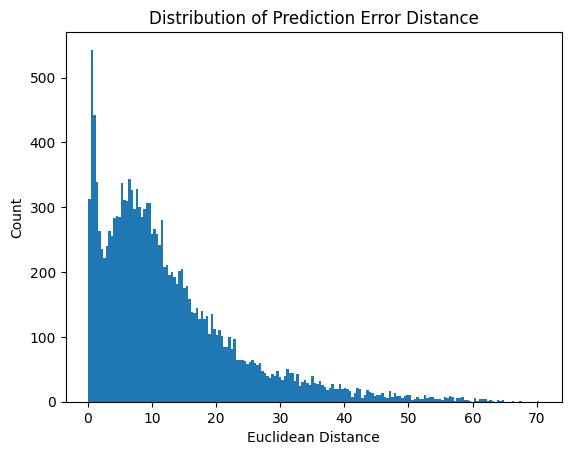

In [ ]:
plt.hist(dist, bins=180)
plt.xlabel("Euclidean Distance")
plt.ylabel("Count")
plt.title("Distribution of Prediction Error Distance")
plt.show()

In [ ]:
fixed_xy_dist = xy_dist.copy()
fixed_xy_dist.loc[manual_estimation.index, :] = manual_estimation
fixed_oof_resid = full_data[['y_0', 'x_0']] - fixed_xy_dist

In [ ]:
# 1. 문제가 되는 인덱스를 리스트로 정의
problem_indices = [8253, 12051, 15262]

# 2. manual_estimation에서 해당 인덱스가 있다면 제외
manual_estimation_filtered = manual_estimation.drop(index=problem_indices, errors='ignore')

# 3. 필터링된 데이터로 할당 진행
fixed_xy_dist.loc[manual_estimation_filtered.index, :] = manual_estimation_filtered
fixed_oof_resid = full_data[['y_0', 'x_0']] - fixed_xy_dist

In [ ]:
dist = np.linalg.norm(fixed_oof_resid, axis=1)
distance = pd.Series(dist)
distance.mean()

np.float64(12.523437411549736)

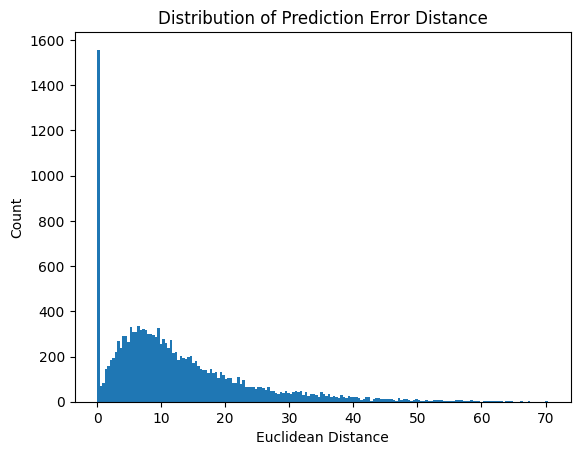

In [ ]:
plt.hist(dist, bins=180)
plt.xlabel("Euclidean Distance")
plt.ylabel("Count")
plt.title("Distribution of Prediction Error Distance")
plt.show()

In [ ]:
predictor_X.leaderboard(X_coord)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForest_r195_BAG_L1,-3.125430,-8.493670,mean_absolute_error,2.483244,2.090029,8.837353,2.483244,2.090029,8.837353,1,True,22
1,RandomForestMSE_BAG_L1,-3.134654,-8.518664,mean_absolute_error,2.594286,0.973670,10.675814,2.594286,0.973670,10.675814,1,True,3
2,ExtraTreesMSE_BAG_L1,-3.152156,-8.568043,mean_absolute_error,2.338711,0.884928,2.509881,2.338711,0.884928,2.509881,1,True,5
3,ExtraTrees_r42_BAG_L1,-3.161113,-8.593694,mean_absolute_error,2.396960,0.865559,2.499210,2.396960,0.865559,2.499210,1,True,18
4,XGBoost_r33_BAG_L1,-4.147749,-8.502921,mean_absolute_error,4.748158,4.337649,24.736098,4.748158,4.337649,24.736098,1,True,17
5,LightGBMLarge_BAG_L1,-5.497409,-8.399785,mean_absolute_error,1.223795,0.654900,8.040062,1.223795,0.654900,8.040062,1,True,9
6,LightGBM_r131_BAG_L1,-6.564207,-8.339070,mean_absolute_error,3.406157,2.145171,8.198868,3.406157,2.145171,8.198868,1,True,12
7,LightGBM_r188_BAG_L1,-6.603622,-8.281939,mean_absolute_error,2.222863,1.607534,9.467493,2.222863,1.607534,9.467493,1,True,23
8,CatBoost_r137_BAG_L2,-6.616789,-8.092599,mean_absolute_error,51.092331,26.859738,1669.523988,0.083182,0.083586,28.397212,2,True,51
9,CatBoost_r177_BAG_L2,-6.624031,-8.094401,mean_absolute_error,51.059419,26.844022,1661.552114,0.050270,0.067871,20.425337,2,True,42


In [ ]:
predictor_Y.leaderboard(Y_coord)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForest_r195_BAG_L1,-3.134583,-8.515251,mean_absolute_error,0.681885,1.853075,6.418889,0.681885,1.853075,6.418889,1,True,22
1,RandomForestMSE_BAG_L1,-3.138528,-8.526497,mean_absolute_error,0.537062,0.718558,9.730379,0.537062,0.718558,9.730379,1,True,3
2,ExtraTrees_r42_BAG_L1,-3.143149,-8.540225,mean_absolute_error,0.626666,0.779483,1.842236,0.626666,0.779483,1.842236,1,True,18
3,ExtraTreesMSE_BAG_L1,-3.144115,-8.542568,mean_absolute_error,0.462312,0.697061,2.348275,0.462312,0.697061,2.348275,1,True,5
4,XGBoost_r33_BAG_L1,-3.890365,-8.471648,mean_absolute_error,4.602285,3.129125,25.230668,4.602285,3.129125,25.230668,1,True,17
5,LightGBMLarge_BAG_L1,-5.148515,-8.432174,mean_absolute_error,1.171144,0.603263,6.021810,1.171144,0.603263,6.021810,1,True,9
6,CatBoost_r137_BAG_L2,-6.166566,-7.848949,mean_absolute_error,60.097990,25.603100,1721.036345,0.087579,0.049939,27.519039,2,True,49
7,CatBoost_r177_BAG_L2,-6.216636,-7.878275,mean_absolute_error,60.066640,25.614637,1711.318890,0.056230,0.061476,17.801584,2,True,40
8,CatBoost_BAG_L2,-6.245636,-7.861225,mean_absolute_error,60.104628,25.617794,1717.589056,0.094218,0.064633,24.071749,2,True,34
9,NeuralNetTorch_r79_BAG_L2,-6.249870,-7.870651,mean_absolute_error,60.648418,25.861090,1756.105975,0.638008,0.307929,62.588669,2,True,41


In [ ]:
X_result = predictor_X.feature_importance(X_coord).sort_values(by='importance', ascending=True)
Y_result = predictor_Y.feature_importance(Y_coord).sort_values(by='importance', ascending=True)
print(X_result)
print(Y_result)

Computing feature importance via permutation shuffling for 13 features using 5000 rows with 5 shuffle sets...
	973.72s	= Expected runtime (194.74s per shuffle set)
	750.77s	= Actual runtime (Completed 5 of 5 shuffle sets)
Computing feature importance via permutation shuffling for 13 features using 5000 rows with 5 shuffle sets...
	959.22s	= Expected runtime (191.84s per shuffle set)
	761.56s	= Actual runtime (Completed 5 of 5 shuffle sets)


               importance    stddev       p_value  n   p99_high    p99_low
cos_error        0.320581  0.013598  3.874632e-07  5   0.348579   0.292584
sin_error        0.337144  0.016775  7.330288e-07  5   0.371684   0.302605
y_speed          0.433429  0.020765  6.302442e-07  5   0.476184   0.390673
x_error          0.445455  0.023251  8.875337e-07  5   0.493330   0.397580
dt_2             0.561413  0.033315  1.480978e-06  5   0.630008   0.492818
sin              0.728770  0.038553  9.363428e-07  5   0.808151   0.649389
x_speed          0.734433  0.013359  1.313034e-08  5   0.761939   0.706927
is_successful    0.891980  0.018105  2.035537e-08  5   0.929258   0.854703
y_1              1.001207  0.041940  3.686287e-07  5   1.087562   0.914851
last_act         1.423424  0.038195  6.215274e-08  5   1.502069   1.344780
dt               1.994813  0.065385  1.383089e-07  5   2.129441   1.860186
x_1              4.436708  0.083660  1.516368e-08  5   4.608965   4.264451
x_2e            10.582239

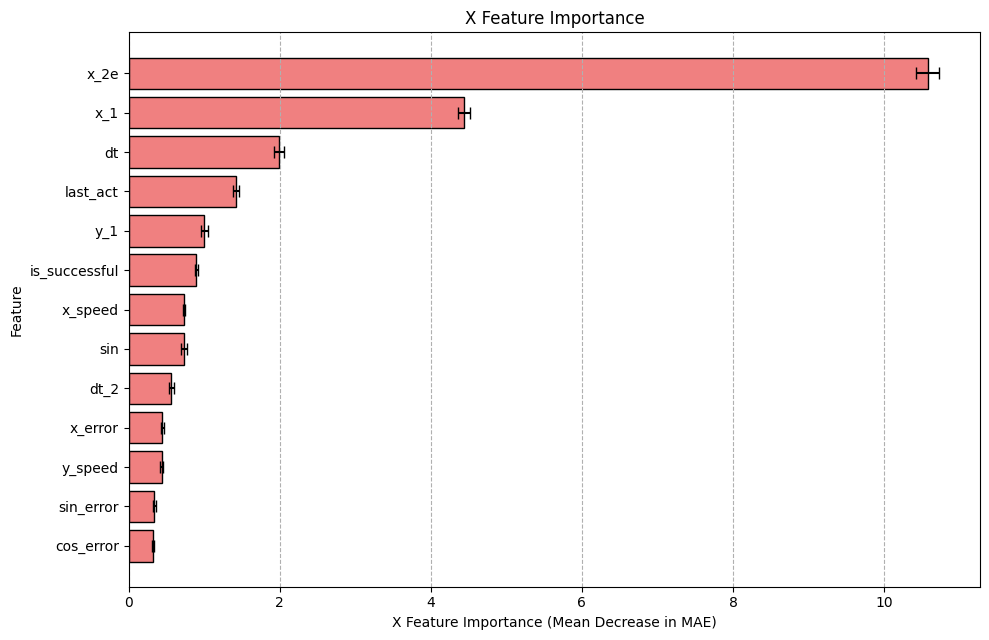

In [ ]:
plt.figure(figsize=(10, X_result.shape[0] * 0.5))
plt.barh(
    X_result.index,
    X_result['importance'],
    xerr=X_result['stddev'],
    capsize=4,
    color='lightcoral',
    edgecolor='black'
)
plt.xlabel('X Feature Importance (Mean Decrease in MAE)')
plt.ylabel('Feature')
plt.title('X Feature Importance')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

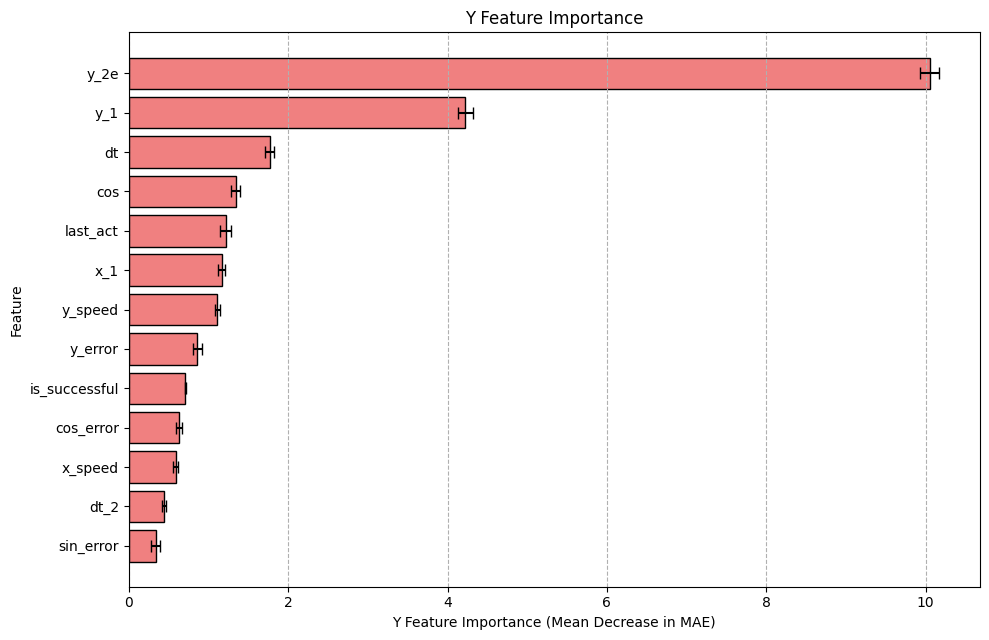

In [ ]:
plt.figure(figsize=(10, Y_result.shape[0] * 0.5))
plt.barh(
    Y_result.index,
    Y_result['importance'],
    xerr=Y_result['stddev'],
    capsize=4,
    color='lightcoral',
    edgecolor='black'
)
plt.xlabel('Y Feature Importance (Mean Decrease in MAE)')
plt.ylabel('Feature')
plt.title('Y Feature Importance')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
#####추론과정#####

In [ ]:
test_meta = pd.read_csv("/content/open_track1_colab/test.csv")
submission = pd.read_csv("/content/open_track1_colab/sample_submission.csv")

submission = submission.merge(test_meta, on="game_episode", how="left")

# Correct the paths in the 'path' column
# The original paths are like './test/153363/153363_1.csv'
# The actual files are in '/content/open_track1_colab/test/...' after unzipping.
# So, we need to prepend '/content/open_track1_colab/' to the path for correct access.
submission['path'] = submission['path'].apply(lambda p: os.path.join('/content/open_track1_colab', p.lstrip('./')))

test_features=preprocess_df(submission, mode='Test')
test_features.head()

Test Files: 100%|██████████| 2414/2414 [00:04<00:00, 596.30it/s]


,x_2e,y_2e,x_1,y_1,sin,cos,dt,x_speed,y_speed,last_act,is_successful,x_error,y_error,cos_error,sin_error,x_3e,y_3e,last_act_2,dt_2
0,61.385415,7.544940,57.801450,9.203664,NaN,NaN,1.033,0.000000,0.000000,TackleUnsuccessful,True,-3.583965,1.658724,0.420015,-0.907517,57.801450,9.203664,Carry_,0.099
1,19.552575,47.239464,19.552575,47.239464,0.728826,0.684699,1.167,7.639357,7.176826,PassSuccessful,False,0.000000,0.000000,1.000000,0.000000,19.552575,47.239464,Recovery_,0.000
2,20.025705,63.088870,20.025705,63.088870,-0.222726,0.974881,1.255,-0.571853,2.503023,Carry_,False,0.000000,0.000000,1.000000,0.000000,20.743380,59.947576,PassSuccessful,1.454
3,38.639790,8.072620,38.639790,8.072620,0.839228,-0.543779,4.011,7.160094,-4.639394,PassSuccessful,False,0.000000,0.000000,1.000000,0.000000,20.654445,12.799504,TackleUnsuccessful,1.389
4,66.560550,15.260288,66.560550,15.260288,0.800339,-0.599548,3.948,4.848564,-3.632144,Carry_,True,0.000000,0.000000,1.000000,0.000000,47.418420,29.599992,Interception_,0.001


In [ ]:
test_estimation = manual_estimate(test_features)

X_test_coord = coord_extract(test_features, 'X')
Y_test_coord = coord_extract(test_features, 'Y')

X_test_preds = predictor_X.predict(X_test_coord)
Y_test_preds = predictor_Y.predict(Y_test_coord)

XY_test_preds = pd.concat([X_test_preds, Y_test_preds], axis=1)
print("Inference Done.")

Inference Done.


In [ ]:
fixed_XY_test_preds = XY_test_preds.copy()
fixed_XY_test_preds.loc[test_estimation.index, :] = test_estimation

In [ ]:
fixed_XY_test_preds.head()

,x_0,y_0
0,63.585201,11.014696
1,24.181759,54.698265
2,34.705784,65.097198
3,58.811764,4.452951
4,81.501999,8.189809


In [ ]:
submission["end_x"] = fixed_XY_test_preds['x_0']
submission["end_y"] = fixed_XY_test_preds['y_0']
submission[["game_episode", "end_x", "end_y"]].to_csv("/content/open_track1_colab/baseline_submit.csv", index=False)
print("Saved: baseline_submit.csv")

Saved: baseline_submit.csv


In [ ]:
# 20개 제거 예상 :  // 결과 : 12.7925619903
# 30개 제거 예상 : 12.6885384 // 결과 : / 12.8461516965
# 40개 제거 예상 : 12.6646896 // 결과 : 12.819102468
# 50개 제거 : 결과 12.8289291666